# Validação 19 — Regras de segurança e benchmark inicial

## Goal

Validar duas proteções críticas identificadas na auditoria de confiabilidade:

1. evidências classificadas como `UNCERTAIN` não podem, sozinhas, sustentar uma conclusão;
2. artigos com retratação confirmada não podem entrar na síntese científica.

O conjunto usado aqui é um **benchmark determinístico de regressão de segurança**. Ele confirma o comportamento do software em casos conhecidos, mas ainda não mede precisão clínica nem substitui um conjunto ouro revisado por especialistas.

## Setup

Os cenários ficam em `data/reliability_safety_cases.json`. Cada caso declara as relações esperadas e as probabilidades controladas de dois artigos independentes. A execução usa diretamente a síntese e o gerador de relatório do projeto.

### Key Assumptions

- Os rótulos do arquivo são expectativas de engenharia, não anotações clínicas.
- `UNCERTAIN` significa que o classificador não superou simultaneamente confiança e margem mínimas.
- Uma retratação confirmada é um critério de exclusão da síntese, embora continue registrada para auditoria.

In [1]:
import json
import sys
from pathlib import Path

import matplotlib.pyplot as plt
from IPython.display import Markdown, display

project_root = Path.cwd()
if not (project_root / "src").exists():
    project_root = project_root.parent
sys.path.insert(0, str(project_root / "src"))

from fatofake import (
    ArticleContent,
    ArticleEvidenceBundle,
    ArticleQualityProfile,
    ArticleQualityReport,
    EvidenceAssessment,
    EvidenceStatement,
    MultiArticleAnalysisConfig,
    MultiArticleAnalysisService,
    Publication,
    QualityCheck,
    QualityLevel,
    RelationLabel,
    RelationProbabilities,
    ReportSource,
    StudyDesign,
    ValidationStatus,
    generate_evidence_report,
    synthesize_evidence,
)


def show_table(rows, columns):
    header = "| " + " | ".join(columns) + " |"
    separator = "| " + " | ".join("---" for _ in columns) + " |"
    body = [
        "| " + " | ".join(str(row[column]).replace("|", r"\|") for column in columns) + " |"
        for row in rows
    ]
    display(Markdown("\n".join([header, separator, *body])))


cases_path = project_root / "data/reliability_safety_cases.json"
cases = json.loads(cases_path.read_text(encoding="utf-8"))
print(f"Casos carregados: {len(cases)} | fonte: {cases_path.relative_to(project_root)}")

Casos carregados: 5 | fonte: data/reliability_safety_cases.json


## Steps

### 1. Materializar os cenários controlados

Cada registro é transformado em objetos reais de `EvidenceAssessment` e `ArticleQualityProfile`. Assim, o benchmark atravessa exatamente a implementação usada pela aplicação.

In [2]:
def assessment_from(article):
    pmid = article["pmid"]
    probabilities = RelationProbabilities(
        support=article["support"],
        contradiction=article["contradiction"],
        neutral=article["neutral"],
    )
    ranked = sorted(
        (article["support"], article["contradiction"], article["neutral"]),
        reverse=True,
    )
    evidence = EvidenceStatement(
        statement_id=f"statement:{pmid}",
        text="Controlled scientific evidence statement for a safety regression case.",
        extraction_score=1.0,
        matched_claim_terms=("coffee", "prostate"),
        hybrid_rank=1,
        sentence_index=1,
        chunk_id=f"chunk:{pmid}",
        pmid=pmid,
        pmcid=None,
        doi=f"10.1000/{pmid.lower()}",
        section="Results",
        source_url=f"https://example.org/articles/{pmid}",
    )
    return EvidenceAssessment(
        pair_id=f"pair:{pmid}",
        relation=RelationLabel(article["relation"]),
        model_relation=RelationLabel(article["model_relation"]),
        confidence=ranked[0],
        margin=ranked[0] - ranked[1],
        probabilities=probabilities,
        rationale="Cenário controlado do benchmark de segurança.",
        model_name="controlled-safety-benchmark",
        claim="Beber café altera o risco de câncer de próstata.",
        evidence=evidence,
    )


def profile_from(article):
    pmid = article["pmid"]
    return ArticleQualityProfile(
        pmid=pmid,
        level=QualityLevel(article["quality"]),
        study_design="CONTROLLED_BENCHMARK",
        rationale="Qualidade controlada para regressão de segurança.",
        source_url=f"https://example.org/articles/{pmid}",
    )


def evaluate_case(case):
    assessments = [assessment_from(article) for article in case["articles"]]
    profiles = [profile_from(article) for article in case["articles"]]
    synthesis = synthesize_evidence(assessments, profiles)
    sources = [
        ReportSource(
            label=f"Fonte controlada {article['pmid']}",
            url=f"https://example.org/articles/{article['pmid']}",
            pmid=article["pmid"],
        )
        for article in case["articles"]
    ]
    report = generate_evidence_report(
        "Beber café altera o risco de câncer de próstata.",
        synthesis,
        (),
        sources,
        additional_limitations=("Cenário sintético de regressão; não é evidência clínica.",),
    )
    usable_articles = sum(
        article.uncertain_count < article.assessment_count
        for article in synthesis.articles
    )
    passed = (
        synthesis.direction.value == case["expected_direction"]
        and synthesis.strength.value == case["expected_strength"]
        and report.conclusion.value == case["expected_conclusion"]
    )
    unsafe_conclusions = {
        "COMPATIBLE_WITH_EVIDENCE",
        "INCOMPATIBLE_WITH_EVIDENCE",
    }
    false_reassurance = (
        case["safety_critical"]
        and case["expected_conclusion"] not in unsafe_conclusions
        and report.conclusion.value in unsafe_conclusions
    )
    return {
        "caso": case["case_id"],
        "artigos utilizáveis": usable_articles,
        "direção esperada": case["expected_direction"],
        "direção obtida": synthesis.direction.value,
        "força esperada": case["expected_strength"],
        "força obtida": synthesis.strength.value,
        "conclusão esperada": case["expected_conclusion"],
        "conclusão obtida": report.conclusion.value,
        "passou": passed,
        "falsa segurança": false_reassurance,
    }


results = [evaluate_case(case) for case in cases]
show_table(
    results,
    [
        "caso",
        "artigos utilizáveis",
        "direção obtida",
        "força obtida",
        "conclusão obtida",
        "passou",
    ],
)

| caso | artigos utilizáveis | direção obtida | força obtida | conclusão obtida | passou |
| --- | --- | --- | --- | --- | --- |
| all_uncertain_support_signal | 0 | MIXED | INSUFFICIENT | INSUFFICIENT_EVIDENCE | True |
| one_confident_one_uncertain | 1 | SUPPORTS | INSUFFICIENT | INSUFFICIENT_EVIDENCE | True |
| two_confident_support | 2 | SUPPORTS | MODERATE | COMPATIBLE_WITH_EVIDENCE | True |
| confident_conflict | 2 | MIXED | LOW | CONFLICTING_EVIDENCE | True |
| two_confident_neutral | 2 | NEUTRAL | MODERATE | INCONCLUSIVE | True |

### 2. Medir regressões e falsa segurança

A métrica prioritária nesta fase é a quantidade de cenários conservadores que terminam incorretamente em uma conclusão de compatibilidade ou incompatibilidade. O valor esperado é zero.

| métrica | valor |
| --- | --- |
| casos aprovados | 5/5 |
| taxa de aprovação | 100.0% |
| casos críticos | 4 |
| falsas seguranças | 0 |

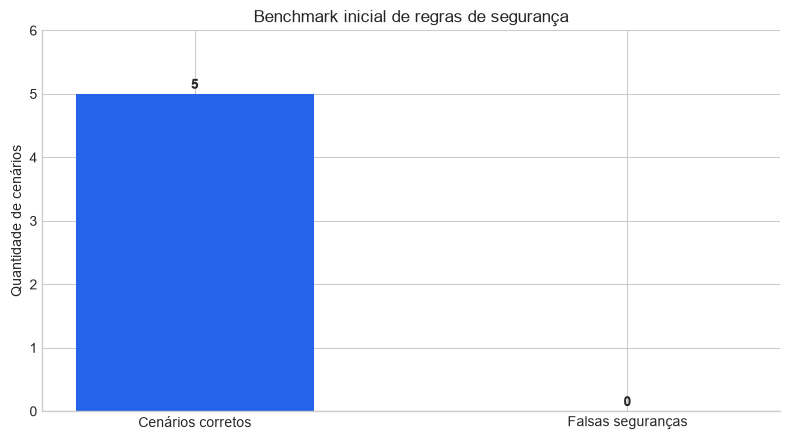

In [3]:
total_cases = len(results)
passed_cases = sum(result["passou"] for result in results)
false_reassurance_count = sum(result["falsa segurança"] for result in results)
safety_cases = sum(case["safety_critical"] for case in cases)

metrics = [
    {"métrica": "casos aprovados", "valor": f"{passed_cases}/{total_cases}"},
    {"métrica": "taxa de aprovação", "valor": f"{passed_cases / total_cases:.1%}"},
    {"métrica": "casos críticos", "valor": safety_cases},
    {"métrica": "falsas seguranças", "valor": false_reassurance_count},
]
show_table(metrics, ["métrica", "valor"])

plt.style.use("seaborn-v0_8-whitegrid")
fig, ax = plt.subplots(figsize=(8, 4.5))
labels = ["Cenários corretos", "Falsas seguranças"]
values = [passed_cases, false_reassurance_count]
colors = ["#2563EB", "#DC2626"]
bars = ax.bar(labels, values, color=colors, width=0.55)
ax.set_title("Benchmark inicial de regras de segurança")
ax.set_ylabel("Quantidade de cenários")
ax.set_ylim(0, max(total_cases, 1) + 1)
for bar, value in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width() / 2, value + 0.08, str(value), ha="center", fontweight="bold")
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

### 3. Validar a exclusão de retratações no serviço multiartigo

O primeiro candidato abaixo possui uma retratação confirmada. O serviço deve registrá-lo como falha de elegibilidade, continuar a busca e sintetizar somente os dois artigos seguintes.

In [4]:
def publication(pmid):
    return Publication(
        pmid=pmid,
        title=f"Controlled article {pmid}",
        authors=("Safety Reviewer",),
        journal="Controlled Journal",
        publication_date="2026",
        doi=f"10.1000/{pmid.lower()}",
        url=f"https://pubmed.ncbi.nlm.nih.gov/{pmid}/",
        matched_queries=("coffee AND prostate cancer",),
    )


def bundle(pmid, *, retracted=False):
    item = publication(pmid)
    article = {
        "pmid": pmid,
        "relation": "SUPPORTS",
        "model_relation": "SUPPORTS",
        "support": 0.80,
        "contradiction": 0.10,
        "neutral": 0.10,
        "quality": "MODERATE",
    }
    quality = ArticleQualityReport(
        pmid=pmid,
        doi=item.doi,
        study_design=StudyDesign.OBSERVATIONAL,
        quality_level=QualityLevel.LOW if retracted else QualityLevel.MODERATE,
        checks=(
            QualityCheck(
                name="retraction",
                status=ValidationStatus.CONFIRMED if retracted else ValidationStatus.NOT_FOUND,
                summary="Retratação confirmada." if retracted else "Nenhuma retratação localizada.",
                source_url=f"https://doi.org/{item.doi}",
            ),
        ),
        datasets=(),
        trial_registrations=(),
        rationale="Retratado." if retracted else "Controle sem retratação.",
    )
    content = ArticleContent(
        pmid=pmid,
        pmcid=None,
        doi=item.doi,
        abstract="Controlled abstract.",
        full_text=None,
        sections=(),
        access_level="ABSTRACT_ONLY",
        pubmed_url=item.url,
        pmc_url=None,
    )
    return ArticleEvidenceBundle(
        publication=item,
        content=content,
        assessments=(assessment_from(article),),
        quality_report=quality,
    )


class FixedPlanner:
    def generate_queries(self, _claim):
        return ["coffee AND prostate cancer"]


class FixedPubMedClient:
    def __init__(self, publications):
        self.publications = tuple(publications)

    def search_ids(self, _query, *, max_results):
        identifiers = tuple(item.pmid for item in self.publications[:max_results])
        return len(self.publications), identifiers

    def fetch_summaries(self, identifiers, _matched_queries):
        by_id = {item.pmid: item for item in self.publications}
        return tuple(by_id[identifier] for identifier in identifiers)


class FixedProcessor:
    def __init__(self, bundles):
        self.bundles = {item.publication.pmid: item for item in bundles}

    def process(self, publication, _claim):
        return self.bundles[publication.pmid]


candidate_bundles = [
    bundle("90000001", retracted=True),
    bundle("90000002"),
    bundle("90000003"),
]
service = MultiArticleAnalysisService(
    query_planner=FixedPlanner(),
    pubmed_client=FixedPubMedClient([item.publication for item in candidate_bundles]),
    article_processor=FixedProcessor(candidate_bundles),
    config=MultiArticleAnalysisConfig(
        max_results_per_query=3,
        target_articles=2,
        minimum_successful_articles=2,
    ),
)
analysis = service.analyze("Beber café altera o risco de câncer de próstata.")

eligibility_rows = [
    {
        "PMID": item.publication.pmid,
        "retratado": item.quality_report.is_retracted,
        "destino": "síntese",
    }
    for item in analysis.articles
]
eligibility_rows.extend(
    {
        "PMID": failure.pmid,
        "retratado": True,
        "destino": f"excluído: {failure.stage}",
    }
    for failure in analysis.failures
)
show_table(sorted(eligibility_rows, key=lambda row: row["PMID"]), ["PMID", "retratado", "destino"])
print(
    f"Incluídos: {len(analysis.articles)} | "
    f"exclusões por elegibilidade: {sum(f.stage == 'eligibility' for f in analysis.failures)}"
)

| PMID | retratado | destino |
| --- | --- | --- |
| 90000001 | True | excluído: eligibility |
| 90000002 | False | síntese |
| 90000003 | False | síntese |

Incluídos: 2 | exclusões por elegibilidade: 1


## Checks

As verificações falham imediatamente se uma futura alteração permitir que incerteza ou retratação volte a produzir falsa segurança.

In [5]:
assert passed_cases == total_cases
assert false_reassurance_count == 0
assert analysis.report.conclusion.value == "COMPATIBLE_WITH_EVIDENCE"
assert {item.publication.pmid for item in analysis.articles} == {"90000002", "90000003"}
assert len(analysis.failures) == 1
assert analysis.failures[0].pmid == "90000001"
assert analysis.failures[0].stage == "eligibility"
assert "retratação confirmada" in analysis.failures[0].reason.lower()
print("Todas as regras de segurança passaram sem falsa segurança.")

Todas as regras de segurança passaram sem falsa segurança.


## Next Steps

As duas falhas críticas da auditoria agora possuem proteção no código, testes unitários e uma validação executável. O benchmark obteve **100% de aprovação nos 5 cenários controlados e zero falsa segurança**, além de excluir corretamente o artigo retratado.

Este resultado não mede acurácia científica. A próxima expansão deverá criar um conjunto ouro com alegações e artigos reais, anotados independentemente por pelo menos dois revisores da área da saúde. Esse conjunto permitirá medir `Recall@k`, macro-F1, calibração, concordância entre revisores, cobertura da abstenção e taxa de falsa segurança em dados reais.